#**Business Understanding**

## **Contexto y fuente de datos (NHANES 2015–2018)**

El proyecto utiliza datos de la **National Health and Nutrition Examination Survey (NHANES)**, una encuesta transversal representativa de la población de Estados Unidos, diseñada y administrada por el **National Center for Health Statistics (NCHS, CDC)**. NHANES combina:

1. **Entrevistas en el hogar**, con información sociodemográfica, estilos de vida y antecedentes de salud.
2. **Exámenes físicos y de laboratorio** realizados en centros móviles de examen (MEC, *Mobile Examination Centers*), donde se obtienen medidas objetivas (antropometría, presión arterial, laboratorio, etc.).

En este trabajo se emplean **dos ciclos consecutivos de NHANES**:

1. **NHANES 2015–2016**  
   - Archivos con sufijo `_I` (por ejemplo, `DEMO_I`, `BMX_I`, `BPX_I`, `PAQ_I`).

2. **NHANES 2017–2018**  
   - Archivos con sufijo `_J` (por ejemplo, `DEMO_J`, `BMX_J`, `BPX_J`, `PAQ_J`).

En cada ciclo se utilizan los mismos tipos de archivos:

1. `DEMO_I` / `DEMO_J` — **Demographic Data**  
   - Contiene información de:
     1. Edad.
     2. Sexo.
     3. Raza/etnia.
     4. Nivel educacional.
     5. Ingreso familiar y razón ingreso/pobreza.
     6. Variables de diseño muestral (pesos, estratos, etc.).

2. `BMX_I` / `BMX_J` — **Body Measures (BMX)**  
   - Incluye:
     1. Peso.
     2. Talla.
     3. Índice de masa corporal (IMC).
     4. Circunferencia de cintura.
     5. Otras medidas antropométricas.

3. `BPX_I` / `BPX_J` — **Blood Pressure (BPX)**  
   - Registra varias mediciones de:
     1. Presión arterial sistólica.
     2. Presión arterial diastólica.
   - Cada participante puede tener hasta 4 mediciones válidas de SBP y DBP, tomadas bajo un protocolo estandarizado.

4. `PAQ_I` / `PAQ_J` — **Physical Activity Questionnaire (PAQ)**  
   - Contiene:
     1. Actividad física laboral (moderada y vigorosa).
     2. Actividad física de transporte (caminar/bicicleta).
     3. Actividad física recreativa, moderada y vigorosa.
     4. Información de sedentarismo (tiempo sentado/pantalla).

La **unidad básica de análisis** en este proyecto será cada **persona adulta (≥ 18 años)**. Se utilizarán únicamente **mediciones objetivas** (demográficas, antropométricas, presión arterial y actividad física) y no se considerarán:

1. Cuestionarios de diagnóstico autoreportado (por ejemplo, “¿Le han dicho que tiene hipertensión?”).
2. Datos de tratamiento farmacológico.

Esto está en línea con el objetivo de *estimar riesgo* a partir de datos básicos sin depender de diagnósticos previos.



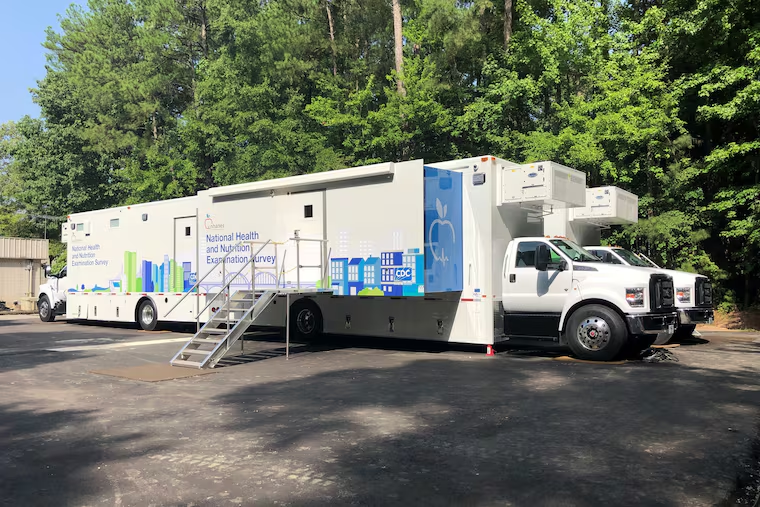

Ref: inquirer.com/health/health-survey-cdc-philadelphia-20250807.html


## **Problema de negocio**

La **hipertensión arterial** es uno de los principales factores de riesgo para:

1. Enfermedad cardiovascular.
2. Enfermedad cerebrovascular.
3. Complicaciones renales y otras comorbilidades crónicas.

Problemas clave desde el punto de vista de negocio y salud pública:

1. Una proporción importante de personas con hipertensión se mantiene **no diagnosticada** o **no controlada**.
2. La medición sistemática de presión arterial en toda la población es costosa y consume recursos (tiempo de personal, equipamiento, visitas).
3. No todos los individuos tienen el mismo riesgo; algunos subgrupos concentran mayor probabilidad de hipertensión.

En este contexto, surge la necesidad de:

1. Estimar el **nivel de presión arterial** y la **probabilidad de hipertensión** utilizando solo variables que son:
   - Fáciles de obtener.
   - Objetivas.
   - Disponibles en un contexto de encuesta rutinaria o atención primaria.
2. Identificar **perfiles de riesgo** que permitan:
   - Definir a quién medir con mayor prioridad.
   - Diseñar intervenciones preventivas más focalizadas.

**Formulación del problema de negocio**:

> Dado un adulto de la población general, con información básica sobre demografía, antropometría y actividad física, ¿es posible estimar su presión arterial sistólica y su probabilidad de hipertensión, sin utilizar diagnósticos previos ni información de tratamiento?


## **Objetivo de negocio**

A partir del problema anterior, el objetivo de negocio se define como:

1. **Objetivo principal**  
   Desarrollar y evaluar modelos de *machine learning* capaces de:

   1. Estimar el valor de **presión arterial sistólica promedio** (`SBP_mean`) de un adulto utilizando características demográficas, antropométricas y de actividad física.
   2. Estimar la **probabilidad de hipertensión arterial** (`HTN_label`), definida exclusivamente a partir de las mediciones de presión arterial (sistólica y diastólica) realizadas en el examen físico, sin recurrir a diagnósticos autoreportados ni uso de fármacos.

2. **Objetivos secundarios**  
   1. Proponer una metodología reproducible (usando Kedro, Docker y Airflow) que permita reentrenar y actualizar los modelos con nuevos ciclos NHANES u otras encuestas similares.
   2. Entregar evidencia cuantitativa que ayude a:
      1. Priorizar grupos de personas para medición de presión.
      2. Entender la contribución relativa de IMC, circunferencia de cintura, actividad física y sedentarismo en el riesgo de hipertensión.

En términos de negocio, el éxito del proyecto se interpreta como la capacidad de:

1. Discriminar correctamente a personas con mayor riesgo de hipertensión (buena sensibilidad y AUC ROC en modelos de clasificación).
2. Aproximar la presión sistólica en un rango de error aceptable (RMSE razonable, R² no trivial) a partir de variables simples.
3. Comunicar resultados de forma comprensible para la toma de decisiones en salud pública y clínica.


## **Objetivos analíticos**

Para operacionalizar el objetivo de negocio se definen los siguientes **objetivos analíticos**:

1. **Objetivo analítico 1 – Regresión (presión sistólica)**  
   - Construir y comparar modelos de **regresión supervisada** que predigan la **presión arterial sistólica promedio (`SBP_mean`)** de cada individuo, calculada a partir de las mediciones disponibles en `BPX_I` y `BPX_J`.
   - Evaluar el desempeño mediante métricas como:
     1. Error cuadrático medio (MSE).
     2. Raíz del error cuadrático medio (RMSE).
     3. Error absoluto medio (MAE).
     4. Coeficiente de determinación (R²).

2. **Objetivo analítico 2 – Clasificación (hipertensión sí/no)**  
   - Construir y comparar modelos de **clasificación supervisada** que estimen la probabilidad de que un individuo presente **hipertensión arterial**, definida exclusivamente a partir de:
     1. `SBP_mean` (presión sistólica promedio).
     2. `DBP_mean` (presión diastólica promedio).
   - La etiqueta binaria `HTN_label` se definirá como:
     - `HTN_label = 1` si `SBP_mean ≥ 140 mmHg` o `DBP_mean ≥ 90 mmHg`.
     - `HTN_label = 0` en caso contrario.
   - Las métricas principales serán:
     1. Área bajo la curva ROC (AUC ROC).
     2. F1-score.
     3. Sensibilidad y especificidad.
     4. Matriz de confusión.

3. **Objetivo analítico 3 – Interpretación de variables**  
   - Analizar la **importancia relativa** de las variables:
     1. Demográficas (edad, sexo, raza/etnia, educación, situación socioeconómica).
     2. Antropométricas (peso, talla, IMC, circunferencia de cintura).
     3. De actividad física y sedentarismo.
   - Identificar qué factores se asocian con:
     1. Mayor presión sistólica (`SBP_mean`).
     2. Mayor probabilidad de hipertensión (`HTN_label`).
   - Explorar posibles **perfiles de riesgo** mediante técnicas de *clustering* en la etapa de modelos no supervisados.


## Supuestos del proyecto

* **Supuestos generales**  
   1. Se asume que las mediciones de presión arterial fueron realizadas correctamente según el protocolo NHANES.
   2. Se asume que la combinación de variables demográficas, antropométricas y de actividad física contiene información suficiente para lograr un desempeño “aceptable” en las tareas de regresión y clasificación, según umbrales definidos en las hipótesis.

Estos supuestos serán revisados y, si es necesario, ajustados en los notebooks de **Data Understanding**, **Data Preparation** y **Modeling**, a partir de la evidencia empírica observada.
